# Carregar as bibliotecas

In [4]:
import numpy as np
from skimage import io, data, filters, util, color, transform
from scipy import ndimage, stats, fft
import matplotlib.pyplot as plt
from skimage.util import img_as_float, img_as_uint, img_as_ubyte

In [5]:
def log_imshow(img):
    return np.log( np.abs(img)+1 )

In [6]:
def mapping(img):
    nimg = img_as_float(img)
    mmin = np.min(nimg)
    nimg = nimg - mmin
    mmax = np.max(nimg)
    return nimg/mmax

In [7]:
def show(img_list, caption_list, Axis=False, rescale = True):
    n = len(img_list)
    f, ax = plt.subplots(1,n, figsize=(10+5*(n-1),10))
    for i in range(n):
        if rescale:
            ax[i].imshow(img_list[i], cmap='gray')
        else:
            if np.max(img_list[i]) <= 1:
                ax[i].imshow(img_list[i], cmap='gray', vmin=0, vmax=1)
            else:
                ax[i].imshow(img_list[i], cmap='gray', vmin=0, vmax=255)
        ax[i].set_title(caption_list[i])
        if not Axis:
            ax[i].set_axis_off()

# Questão 1

<p align="justify">
O função <i>util.random_noise()</i> é utilizada para inserir ruído dentro de uma imagem. Entre os tipos de ruídos implementados está o ruido ``sal e pimenta'' (<i>mode = 's&p'</i>). Este tipo de ruído adiciona pontos brancos e pretos dentro da imagem. Adicione ruído sal e pimenta em uma imagem e remova o ruído inserido utilizando os métodos da mediana e minmax. Logo, compare as imagens resultantes com a imagem original utilizando o erro médio quadrático normalizado.
$$NMSE =\frac{\sum_{x=0}^{M-1}\sum_{y=0}^{N-1} (f(x,y) - g(x,y))^2 }{\sum_{x=0}^{M-1}\sum_{y=0}^{N-1}f(x,y)}$$
</p>

<p align="justify">

</p>

In [8]:
def filtros_median_minmax(noise_img):
  """
    Aplica dois tipos de filtros de suavização em uma imagem ruidosa: filtro mediano e filtro min-max (fechamento morfológico).

    Parâmetros:
    -----------
    noise_img : numpy.ndarray
        Imagem de entrada contendo ruído (geralmente ruído sal-e-pimenta ou impulsivo)

    Retorna:
    --------
    tuple
        (img_median, img_min_max) onde:

        img_median : numpy.ndarray
        img_min_max : numpy.ndarray
"""
  # inserir codigo
  footprint = np.ones((3,3))
  img_median = filters.rank.median(noise_img, footprint=footprint)
  img_min = filters.rank.minimum(noise_img, footprint=footprint)
  img_min_max = filters.rank.median(img_min)
  return img_median, img_min_max

In [9]:
def NMSE(f, g):
  """
    Calcula o Erro Quadrático Médio Normalizado (Normalized Mean Square Error) entre duas imagens.

    Parâmetros:
    -----------
    f, g : numpy.ndarray
        Imagens de entrada para comparação (devem ter o mesmo formato)

    Retorna:
    --------
    float
        NMSE (Erro Quadrático Médio Normalizado) no intervalo [0, ∞)

  """
  # inserir codigo
  f_float = util.img_as_float(f)
  g_float = util.img_as_float(g)
  return np.sum((f_float - g_float)**2) / np.sum(f_float**2)

In [11]:
lenna = io.imread('https://drive.google.com/uc?id=1k0FG4pT6WMjFeG-V63OBXNS7_CvfY5m_', as_gray=True)
clown = io.imread('https://drive.google.com/uc?id=1JIiGsypcTefhq1s1Hk9fQIks8GE5KbuK', as_gray=True)

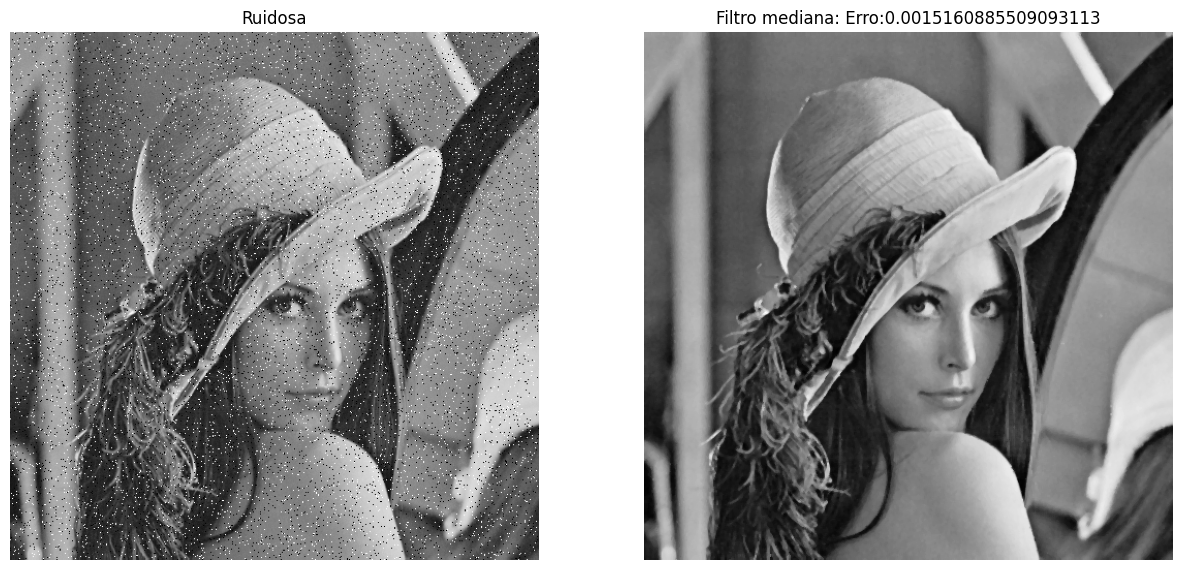

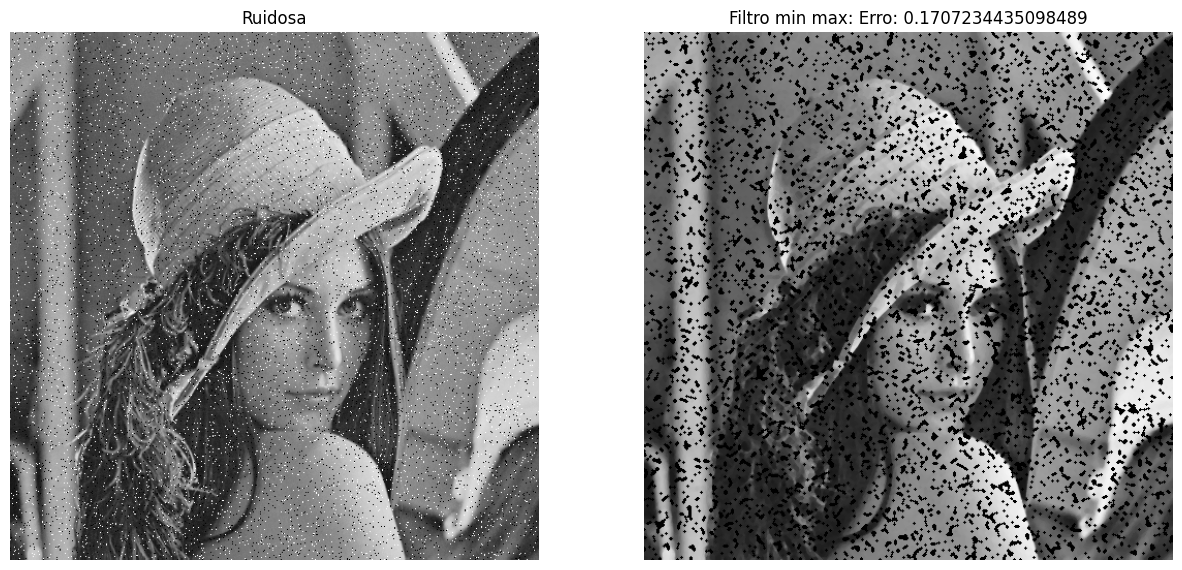

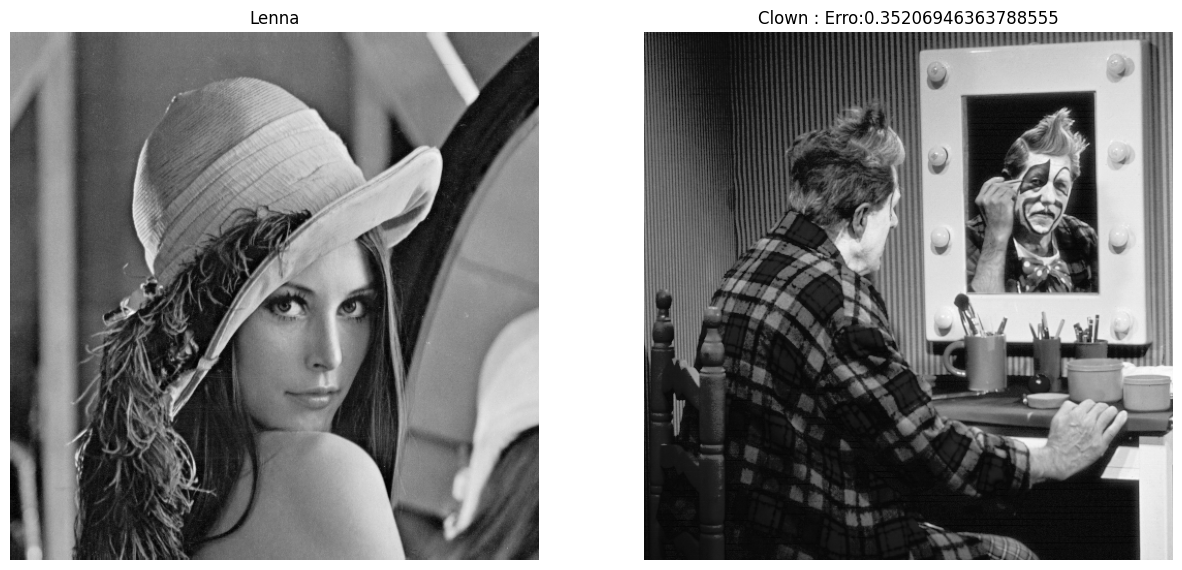

In [12]:
noise_img = img_as_ubyte( util.random_noise(lenna, mode='s&p') )
img_median, img_min_max = filtros_median_minmax(noise_img)

show([noise_img,img_median],['Ruidosa',f'Filtro mediana: Erro:{NMSE(lenna, img_median)}'])
show([noise_img,img_min_max],['Ruidosa',f'Filtro min max: Erro: {NMSE(lenna, img_min_max)}'])
show([lenna, clown],['Lenna',f'Clown : Erro:{NMSE(lenna, clown)}'])


# Questão 2


<p align="justify">
Dada a seguinte imagem, eliminar o ruído produzido pelo ruído periódico. Teste com os seguinte filtros: média, mediana e a filtragem no domínio da frequência. Para o caso da filtragem no domínio da frequência, primeiro calcule o espectro de Fourier (Figura b) e elimine a \textbf{região} ao redor dos ``spikes'' (assinalados com a seta vermelha). Os ``spikes'' estão localizados nas coordenadas (88,88) e (170,170). A terceira imagem mostra o processo depois de apagar esses valores.
Para apagar os valores, basta atribuir zero para todos os elementos da região.
</p>

<p align="justify">

</p>

<table><tr>
<td> <img src="https://drive.google.com/uc?id=1ExhUVoHaj2i4gN1UWC6U7RfP-boZhnRL" alt="Drawing"  width="300"/> </td>
<td> <img src="https://drive.google.com/uc?id=1BGJbV6sXNNlt2PmIZ7RCyHpQfPRpZgJ6" alt="Drawing"  width="300"/> </td>
<td> <img src="https://drive.google.com/uc?id=1d3bAvzHJ5wRwPxIXGZXiUhP7bA5o0SbY" alt="Drawing"  width="300"/> </td>
</tr></table>

In [22]:
def filtragem(img, window_size=5, coord1=(88,88), coord2=(170,170)):
  """
      Retorna:
    --------
    tuple
        (nimg, fimg_shifted) onde:

        nimg : numpy.ndarray
            Imagem reconstruída após a remoção das frequências especificadas (mesmo formato de img),
            representando o resultado da filtragem no domínio da frequência

        fimg_shifted : numpy.ndarray
            Espectro de Fourier modificado (centralizado) com as janelas zeradas, útil para análise
            e visualização do efeito da filtragem no domínio da frequência
  """
  # inserir codigo
  fimg = fft.fft2(img)
  fimg_shifted = fft.fftshift(fimg)
  fimg_shifted[coord1[0]-window_size:coord1[0]+window_size, coord1[1]-window_size:coord1[1]+window_size] = 0
  fimg_shifted[coord2[0]-window_size:coord2[0]+window_size, coord2[1]-window_size:coord2[1]+window_size] = 0
  nimg = np.abs(fft.ifft2(fimg_shifted))
  return nimg, fimg_shifted

In [23]:
lennaR = io.imread('https://drive.google.com/uc?id=1ExhUVoHaj2i4gN1UWC6U7RfP-boZhnRL', as_gray=True)

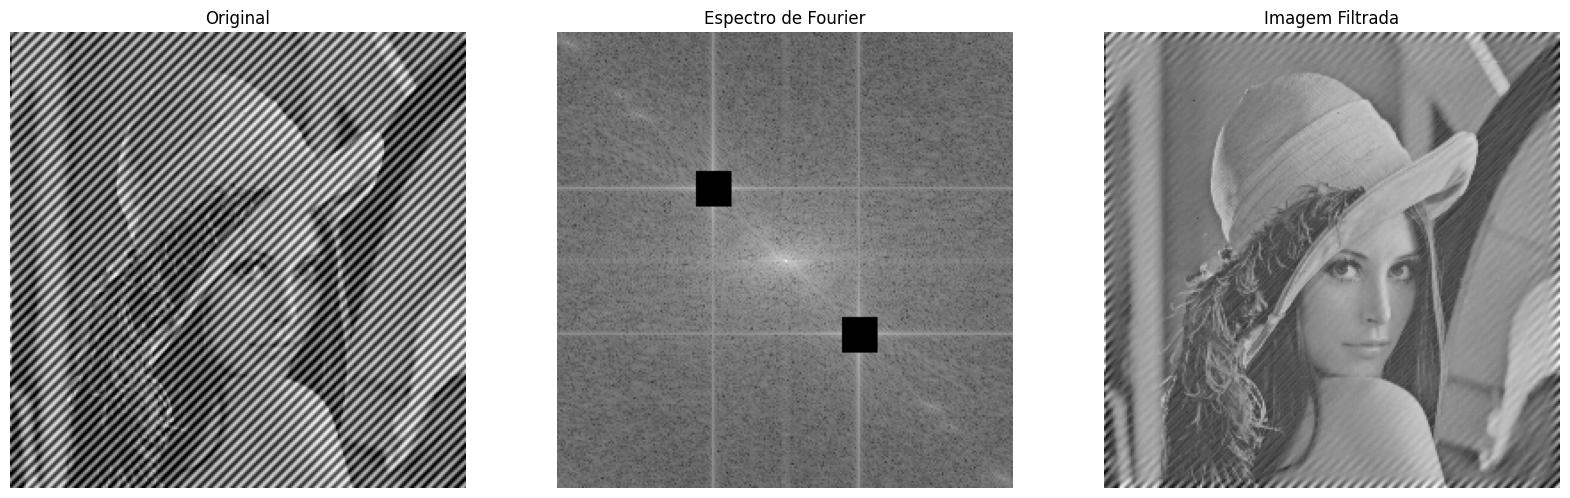

In [28]:
nimg, fimg = filtragem(lennaR, window_size=10)
show([lennaR,log_imshow(fimg),nimg],['Original','Espectro de Fourier','Imagem Filtrada'])

## Questao 3
<p> A ideia principal do $\textit{unsharp masking}$ é que o desfoque da imagem remova os detalhes de uma imagem, mas se adicionarmos esses detalhes de volta à imagem dimensionada por um determinado fator, os detalhes seriam aprimorados e obteríamos uma imagem ``mais nítida''. O  $\textit{unsharp masking}$ é, portanto, definido como abaixo:
$$f + \alpha(f - f*g)$$
onde $f*g$ é a imagem suavizada, $f$ é a imagem original e $\alpha$ é um fator de escala. Implementar a função $\textit{unsharp masking}$. Usar o filtro passa-baixas Gaussiano para suavizar a imagem.
</p>

In [40]:
def passa_freq(img, mask):
    height, width = img.shape[:2]
    fimg = fft.fftshift( fft.fft2(img) )
    fimg = fimg * mask
    nimg = fft.ifft2(fimg)
    nimg = np.abs(nimg)
    return nimg, fimg

In [41]:
def gridFourier(M, N):
    u = np.arange(0, M)
    v = np.arange(0, N)

    u = u - np.floor(M/2)
    v = v - np.floor(N/2)
    U, V = np.meshgrid(u, v)
    return U, V

In [42]:
def mask_gaussiana(width, height, sigma):
    U, V = gridFourier(width, height)
    D = np.sqrt(U**2 + V**2)
    H = np.exp( -D**2/(2*sigma**2)  )
    return H

In [47]:
def highboost(img, radio = 30, alpha = 1):
   # inserir codigo
   height, width = img.shape[:2]
   H = mask_gaussiana(width,height,radio)
   f_suavizada, _ = passa_freq(img, H)
   f = img + alpha * (img - f_suavizada)
   f = np.clip(f, 0, 1)
   return f

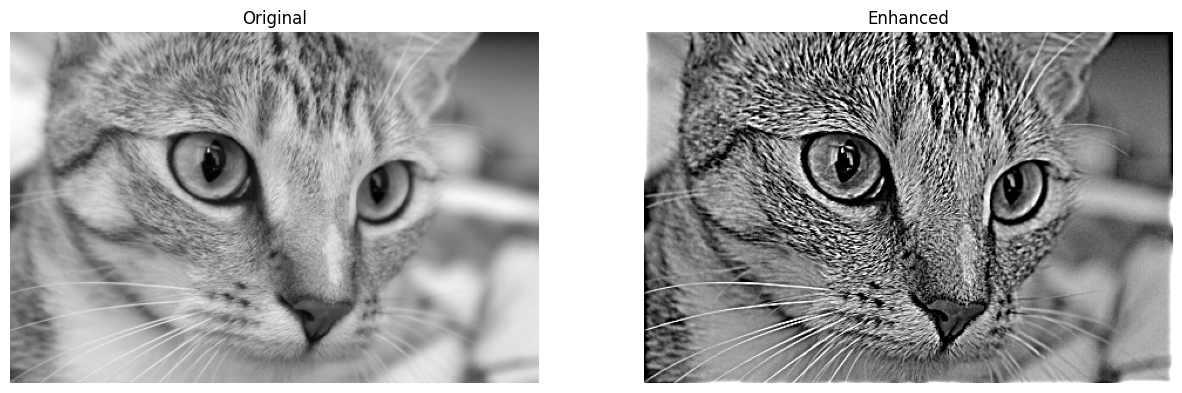

In [48]:
img = data.chelsea()
img = color.rgb2gray(img)
nimg = highboost(img, radio = 30, alpha = 5)
show([img,nimg],['Original','Enhanced'])

### Questão 4


https://www.eletrica.ufpr.br/marcelo/TE072/022007/Rodrigo-Halftoning.pdf

<p>O halftoning é uma técnica usada para simular imagens em tons de cinza ou cores contínuas usando apenas tons binários (preto e branco). Uma das formas mais eficazes de realizar o halftoning é através da difusão de erro, onde o erro de quantização de um pixel é distribuído para seus vizinhos ainda não processados, de acordo com uma matriz de difusão.</p>

<p>
Nesta atividade, você deverá implementar a técnica de halftoning por difusão de erro, utilizando a máscara de difusão proposta por Rogers.</p>

<p>A máscara de Rogers distribui o erro do pixel atual para os vizinhos da seguinte forma:</p>
\begin{bmatrix}
\bullet  & 3/8\\
 3/8 & 2/8
\end{bmatrix}

<p>Considere que o pixel atual está marcado com $\bullet$. O erro de quantização é distribuído para os três vizinhos indicados.</p>

<p>
<b>Roteiro para Implementação</b>
<ol>
<li>Pré-processamento:</li>
  <ul>
  <li>Converta a imagem de entrada para o tipo float, com valores normalizados entre 0 e 1.</li>
  </ul>
<li>Iteração sobre os pixels:</li>
  <ul>
  <li>Percorra a imagem pixel a pixel, ignorando a última linha e coluna para evitar acessos fora dos limites.</li>
  </ul>  
<li>Quantização binária:</li>
  <ul>
  <li>Compare o valor do pixel com um limiar (threshold, ex: 0.5).</li>
      <ul>
      <li>Se o valor do pixel for menor que o limiar, defina o valor binarizado como 0.</li>
      <li>Caso contrário, defina o valor como 1.</li>
      </ul>
  </ul>
<li>Cálculo do erro:</li>
  <ul>
  <li>O erro de quantização é calculado como:</li>
  $erro = valor\_original - valor\_binarizado$
  </ul>
<li>Difusão do erro:</li>
  <ul>
  <li>Distribua o erro para os pixels vizinhos segundo a máscara de Rogers:</li>
  \begin{matrix}
  a[i, j+1]   &+= 3/8 * erro\\
  a[i+1, j]   &+= 3/8 * erro\\
  a[i+1, j+1] &+= 2/8 * erro
  \end{matrix}

  </ul>
<li>Resultado:</li>
  <ul>
  <li>Retorne a imagem binarizada com os valores 0 e 1.</li>
  </ul>
</ol>
</p>

In [53]:
def halftone_rogers(img, thresh=0.5):
  # Pré-processamento: copia a imagem como float
  a = img.astype(float).copy()
  height, width = a.shape

  # Imagem binarizada de saída
  b = np.zeros_like(a)

  # Itera sobre os pixels (ignorando última linha e coluna)
  for i in range(height - 1):
    for j in range(width - 1):
      valor_original = a[i, j]

      # Quantizacao binária
      valor_binarizado = 0 if valor_original < thresh else 1
      b[i,j] = valor_binarizado

      # Cálculo do erro
      erro = valor_original - valor_binarizado

      # Difusao do erro (mascara de Rogers)
      a[i, j+1] += 3/8 * erro
      a[i+1, j] += 3/8 * erro
      a[i+1, j+1] += 2/8 * erro
      
  return b

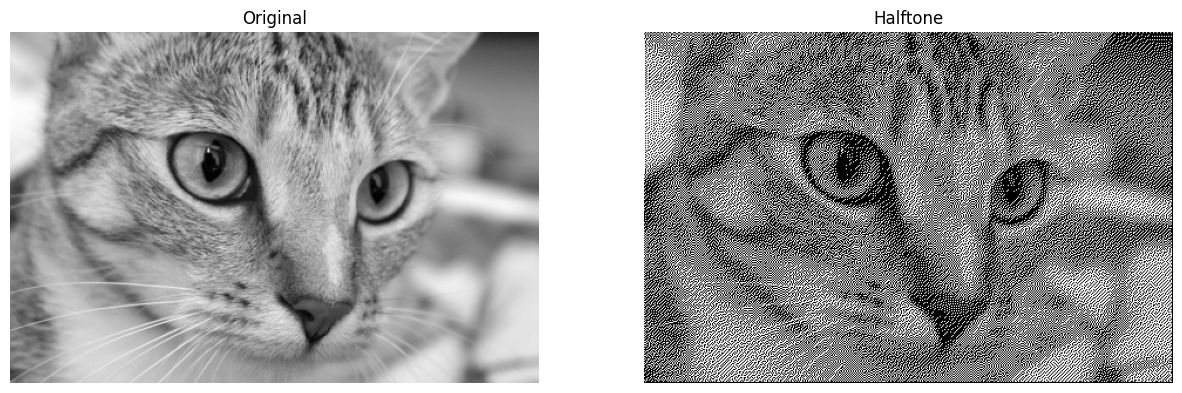

In [54]:
img = color.rgb2gray(data.chelsea())
nimg = halftone_rogers(img, 0.3)
show([img,nimg],['Original','Halftone'])

# Questão 5

<p>A Transformada de Fourier é uma ferramenta fundamental em processamento de imagens que decompõe uma imagem em suas frequências espaciais constituintes. Neste exercício, você explorará como diferentes transformações geométricas (rotação, translação) e diferentes formas (letras) afetam o espectro de Fourier, utilizando a similaridade de cossenos como métrica de comparação.</p>

Objetivos
<ol>
<li>Implementar a métrica de similaridade de cossenos</li>
<li>Analisar o efeito da rotação no espectro de Fourier</li>
<li>Comparar diferentes formas geométricas via seus espectros</li>
<li>Investigar a invariância à translação da Transformada de Fourier</li>
<li>Explorar a representação em coordenadas polares do espectro</li>
</ol>

<p>A similaridade de cossenos é definida da seguinte forma:
$$\frac{\sum{A*B}}{\sqrt{\sum{A^2}} \sqrt{\sum{B^2}}}$$
onde $A$ e $B$ são vetores.

Interpretação:
<ul>
<li>1.0 → Vetores perfeitamente similares (mesma direção)</li>
<li>0.0 → Vetores ortogonais (sem correlação)</li>
</ul>

### 1. Similaridade de cossenos

In [30]:
def cosine_similarity(vector_a, vector_b):
    """
    Calcula a similaridade de cossenos entre dois vetores.

    Parâmetros:
    -----------
    vector_a, vector_b : numpy.ndarray
        Vetores de entrada (podem ser 1D ou 2D)

    Retorna:
    --------
    float
        Similaridade de cossenos no intervalo [-1, 1]
    """
    num = np.sum(vector_a * vector_b)
    den = np.sqrt(np.sum(vector_a**2)) * np.sqrt(np.sum(vector_b**2))
    return num/den
    # inserir codigo

### 2. Efeito da Rotação no Espectro de Fourier
<p>
<ol>
<li>Leia a imagem da letra 'A' (binária, fundo preto, letra branca)</li>
<li>Rotacione a imagem em 45° e 75°</li>
<li>Calcule a Transformada de Fourier de cada versão (original e rotacionadas)</li>
<li>Calcule a similaridade de cossenos entre:</li>
  <ul>
  <li>Original vs Rotação 45°</li>
  <li>Original vs Rotação 75°</li>
  </ul>
</ol>

Pergunta teórica: O que você observa? O espectro de Fourier rotaciona junto com a imagem?
</p>

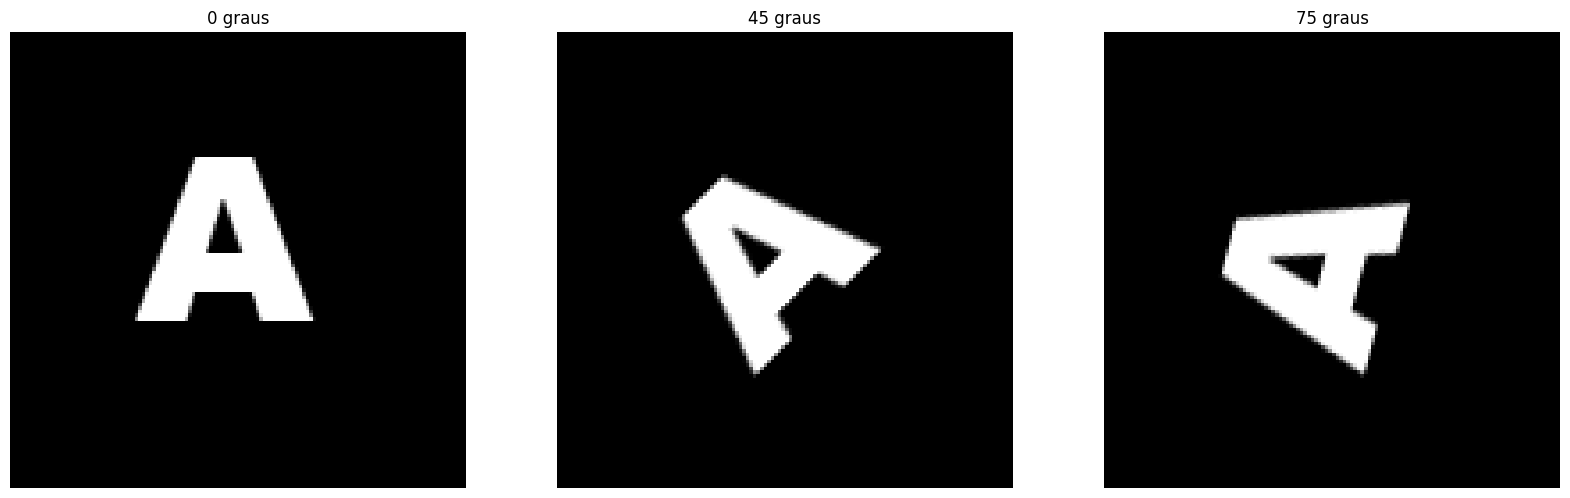

In [31]:
A = io.imread('https://drive.google.com/uc?id=1h4QeEvRgB7wbAY9MocKGaaKDdniiQWQ6', as_gray = True)
A_45 = transform.rotate(A, 45)
A_75 = transform.rotate(A, 75)
show([A, A_45, A_75],['0 graus','45 graus','75 graus'])

In [32]:
fA = fft.fft2(A)
fA_45 = fft.fft2(A_45)
fA_75 = fft.fft2(A_75)

print(f'Distancia entre A e A45: {cosine_similarity(np.abs(fA), np.abs(fA_45))}')
print(f'Distancia entre A e A75: {cosine_similarity(np.abs(fA), np.abs(fA_75))}')

Distancia entre A e A45: 0.9227902355484546
Distancia entre A e A75: 0.92147117398149


###3: Comparação entre Diferentes Letras

<p>
<ol>
<li>Leia as imagens 'B' e 'V'</li>
<li>Calcule a Transformada de Fourier das letras 'B' e 'V'</li>
<li>Calcule a similaridade de cossenos entre todos os pares:</li>
  <ul>
  <li>A vs B</li>
  <li>A vs V</li>
  </ul>
</ol>

Pergunta teórica: Quais letras têm espectros mais similares? Por quê?
</p>

Distancia entre A e B: 0.9128478779289086
Distancia entre A e V: 0.9707504375773455


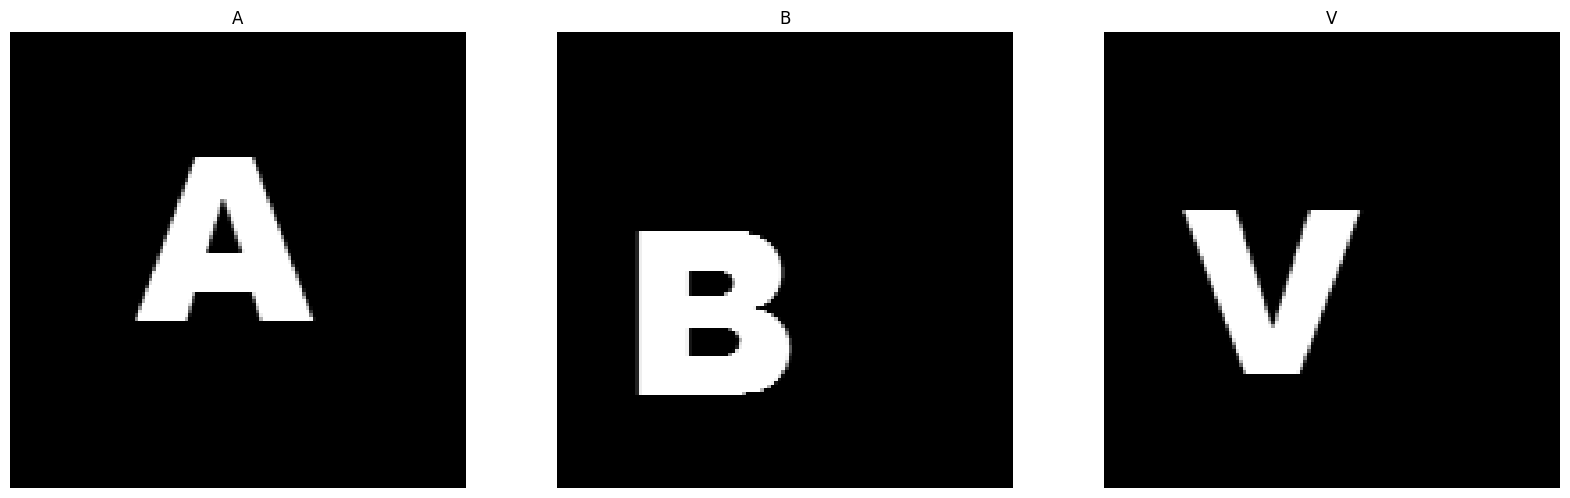

In [33]:
# Passo 1
B = io.imread('https://drive.google.com/uc?id=1WV7pcoGXW6cJh74OjBwiD41gGcXfRMft', as_gray = True)
V = io.imread('https://drive.google.com/uc?id=1V5hZKGaQ-wlCjVnYgOG6WnnPih5nF7ET', as_gray = True)
show([A, B, V],['A','B','V'])
# Passo 32
fB = fft.fft2(B)
fV = fft.fft2(V)
# Passo 3
print(f'Distancia entre A e B: {cosine_similarity(np.abs(fA), np.abs(fB))}')
print(f'Distancia entre A e V: {cosine_similarity(np.abs(fA), np.abs(fV))}')

###3: Invariância à Translação da Transformada de Fourier

<p>
<ol>
<li>Leia as imagens 'B_t' traslada</li>
<li>Calcule a Transformada de Fourier das letras 'B_t'</li>
<li>Calcule a similaridade de cossenos entre os pares: B e B_t</li>
</ol>

</p>

Distancia entre B e Bt: 0.9999999999999999


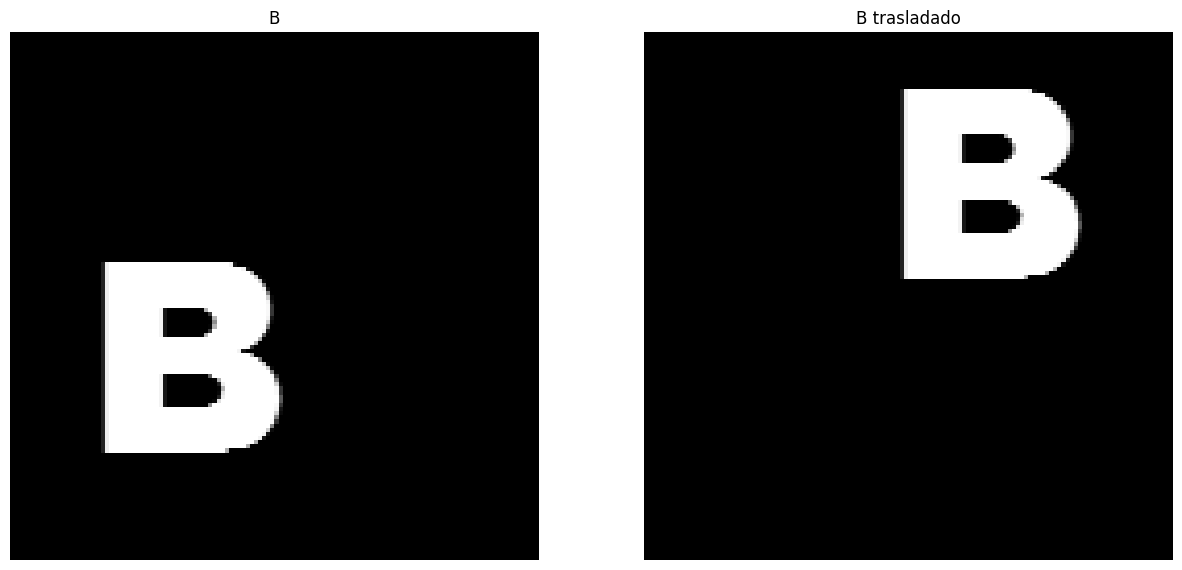

In [34]:
# Passo 1
Bt = io.imread('https://drive.google.com/uc?id=1soqJU7p5e59FBYBi1f5g34_4en8Q1e0k', as_gray = True)
show([B, Bt],['B','B trasladado'])
# Passo 2
fBt = fft.fft2(Bt)
# Passo 3
print(f'Distancia entre B e Bt: {cosine_similarity(np.abs(fB), np.abs(fBt))}')

###3: Coordenadas polares

<p>A transformação para coordenadas polares representa uma imagem em termos de raio (distância ao centro) e ângulo (orientação), em vez das coordenadas cartesianas tradicionais (x, y). Esta representação é particularmente útil para analisar padrões circulares e para tornar certas transformações geométricas (como rotações) mais fáceis de detectar.
<ol>
<li>Converter as imagens de letras A do sistema cartesiano para polar. Use a função <i>skimage.transform.warp_polar((image, output_shape=None))</i>. Fixe o tamanho das imagens resultante para $128 \times 128$ (tamanho original das imagens), faça isso atribuindo: <i>output_shape=(128,128)</i></li>
<li>Analisar como diferentes rotações afetam o espectro de Fourier no domínio polar</li>
<li>Calcule a similaridade de cossenos entre os pares:</li>
  <ul>
  <li>Original vs Rotação 45°</li>
  <li>Original vs Rotação 75°</li>
  </ul>
</ol>

</p>

Propriedade importante: Uma rotação no domínio cartesiano torna-se uma translação circular no domínio polar!


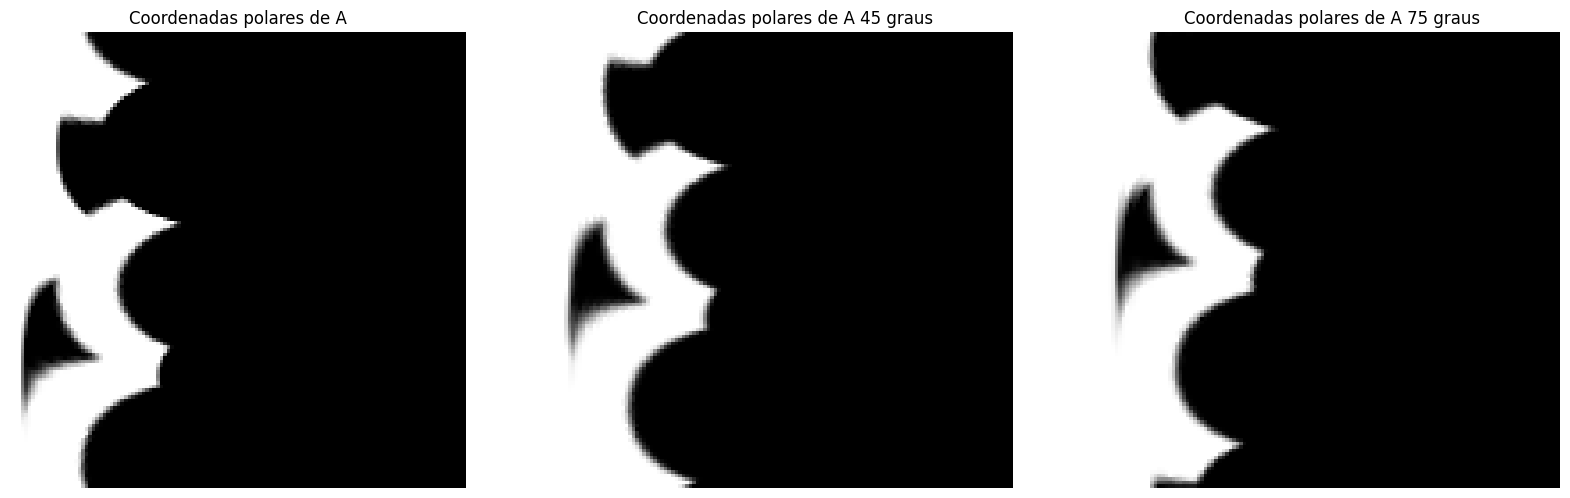

In [35]:
# Passo 1
Ap = transform.warp_polar(A, output_shape=(128,128))
A_45p = transform.warp_polar(A_45, output_shape=(128,128))
A_75p = transform.warp_polar(A_75, output_shape=(128,128))
show([Ap,A_45p,A_75p],['Coordenadas polares de A', 'Coordenadas polares de A 45 graus', 'Coordenadas polares de A 75 graus'])
print('Propriedade importante: Uma rotação no domínio cartesiano torna-se uma translação circular no domínio polar!')

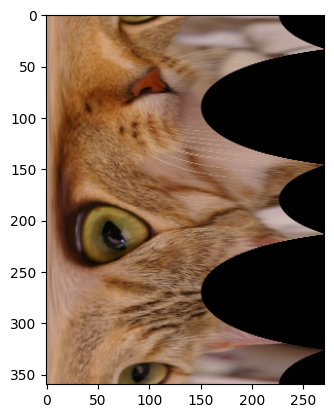

In [37]:
img = data.chelsea()
pimg = transform.warp_polar(img, channel_axis=2)
plt.imshow(pimg)

In [36]:
# Passo 2
fAp = fft.fft2(Ap)
fA_45p = fft.fft2(A_45p)
fA_75p = fft.fft2(A_75p)
# Passo 3
print(f'Distancia entre A e A45: {cosine_similarity(np.abs(fAp), np.abs(fA_45p))}')
print(f'Distancia entre A e A75: {cosine_similarity(np.abs(fAp), np.abs(fA_75p))}')

Distancia entre A e A45: 0.9994103253866093
Distancia entre A e A75: 0.9994097639836443


# Questão 6

<p>O efeito sépia é uma técnica de tonalização que confere às imagens fotográficas um aspecto envelhecido, característico das fotografias do século XIX e início do século XX. O nome deriva da tinta marrom-avermelhada produzida pela sépia (molusco marinho), que era utilizada no processo de tonificação para aumentar a durabilidade das imagens e dar-lhes esse tom característico.

Atualmente, o efeito sépia é amplamente utilizado em:
<ol>
<li>Filtros de redes sociais (Instagram, TikTok)</li>
<li>Produções cinematográficas para cenas de época</li>
<li>Restauração digital de fotografias antigas</li>
<li>Design gráfico para efeitos vintage/retrô</li>
</ol>
</p>

<p>Implementar um algoritmo que converta uma imagem colorida (RGB) para o estilo sépia, simulando o aspecto de fotografias antigas, utilizando apenas operações aritméticas e matriciais (sem funções prontas de conversão).</p>

<p><b>O que é o Efeito Sépia?</b></p>

<p>O efeito sépia é uma tonalização monocromática que transforma uma imagem colorida em tons de marrom-avermelhado, variando do marrom claro (quase bege) ao marrom escuro (quase preto).</p>

<p><b>Fórmula Matemática</b></p>
<p>
Para converter uma imagem colorida para sépia, utilizamos a seguinte transformação linear. Dados os canais R (Vermelho), G (Verde), B (Azul) de um pixel, os novos valores sépia são calculados por:</p>

$$\begin{eqnarray}
R_{sepia} & = & 0.393 R + 0.769 * G + 0.189 * B \\
G_{sepia} & = & 0.349 R + 0.686 * G + 0.168 * B \\
B_{sepia} & = & 0.272 R + 0.534 * G + 0.131 * B \\
\end{eqnarray}$$

In [57]:
def to_sepia_tone(img):
    # Matriz de transformacao sepia
    sepia_matrix = np.array([
        [0.393, 0.769, 0.189],
        [0.349, 0.686, 0.168],
        [0.272, 0.543, 0.131]
    ])

    # Normaliza para [0,1] se necesario
    if img.max() > 1:
        img = img / 255.0

    # Aplica a transformacao: cada pixel (R, G, B) -> (R_s, G_s, B_s)
    nimg = img.reshape(-1, 3) @ sepia_matrix.T
    nimg = nimg.reshape(img.shape)

    nimg = np.clip(nimg, 0, 1)

    return nimg

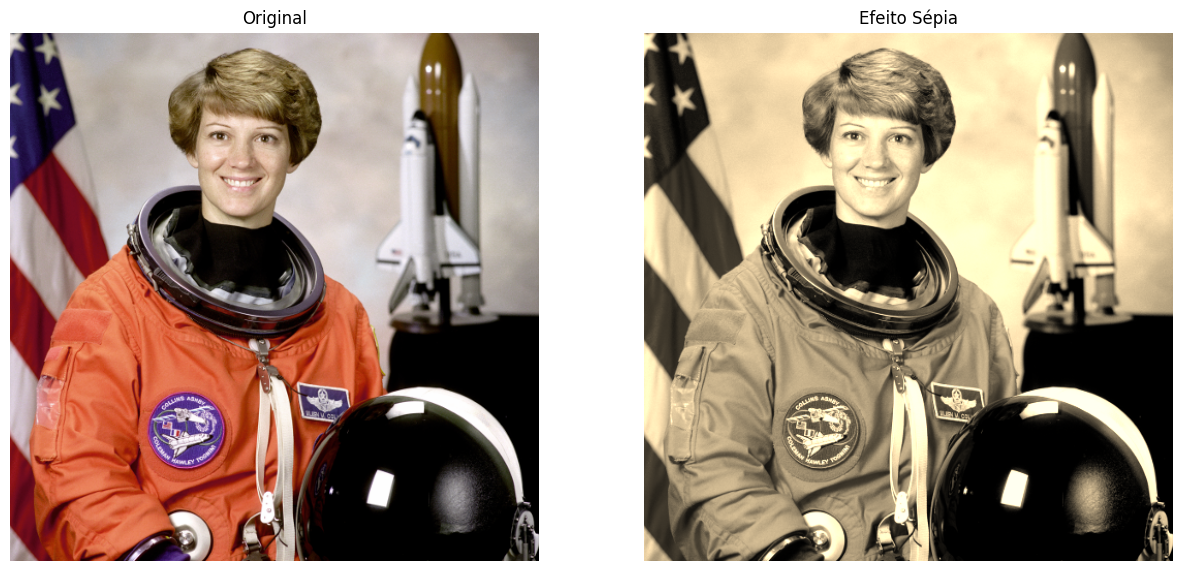

In [58]:
img = data.astronaut()
nimg = to_sepia_tone(img)
show([img, nimg],['Original','Efeito Sépia'])